# Tutorial 2

**Matched Filtering**
- Simulate GW data containing a CBC signal.
- Calculate matched filter SNR.

**Same GW signal, different projections**
- Detector-dependent projection $h_d(t) = F_+^d h_+ + F_\times^d h_\times$
- Same source, different projections across detectors


> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [1]:
# !pip install pycbc ligo.skymap

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.psd import aLIGOZeroDetHighPower, AdVDesignSensitivityP1200087
from pycbc.noise.gaussian import frequency_noise_from_psd
from pycbc.filter import matched_filter
from pycbc.detector import Detector
from pycbc.waveform.generator import (FDomainDetFrameGenerator, FDomainCBCGenerator)
import ligo.skymap.plot

%matplotlib inline


/home/abhishek.sharma/miniconda3/envs/gw-env/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
# Function to whiten a frequency series `freqSeries` colored with `PSD`.
def whiten(freqSeries, PSD):
    
    PSD.data[np.where(PSD.data == 0)[0]] = 10**(-50)
    whiten_strain = (freqSeries / (PSD/freqSeries.delta_t/2) ** 0.5).to_timeseries()
    
    return whiten_strain

We will:
- generate a time-domain BBH waveform. 
- add it to Gaussian noise colored with an analytic detector PSD.
- compute SNR time series with the correct template and with mismatched templates.
- demonstraite that the difference in arrival time of the GW signal in two detectors encode information of sky position of the source.


In [4]:
# parameters of the binary...
m1, m2, s1z, s2z = 20, 10, 0.4, -0.1         # intrinsic parameters
distance = 800                               # luminosity distance (in Mpc)
ra = 3.44626                                 # Right Ascension
dec = -0.408084                              # Declination
psi = 2.28121                                # Polarization angle
tc = 1464266451                              # coalescence time (geocentric frame)
iota= 2.4975                                 # inclination angle
phic = 0.2                                   # coalescence phase
epoch = tc - 32

flow, fhigh = 20, 1024                       # min, max frequencies
fsamp = 2*fhigh
duration = 64
delta_f = 1/duration
Nt = fsamp * duration
Nf = int(Nt//2 + 1)

frozenParams= {'approximant' : "IMRPhenomD", 'mass1' : m1, 'mass2' : m2, 'spin1z' : s1z, 'spin2z' : s2z, \
                'delta_f' : delta_f, 'f_lower' : flow, 'f_final' : fhigh, 'inclination' : iota, 'distance' : distance, \
               'coa_phase':phic, 'ra': ra, 'dec': dec, 'tc':tc, 'polarization':psi}

ifos = ['L1', 'H1']

generator = FDomainDetFrameGenerator(FDomainCBCGenerator, detectors = ifos, epoch = epoch, **frozenParams)

# Generate the signal in ifos.
gw_signal = generator.generate()

# resize if length in frequency domain is not same as Nf.
if len(gw_signal['L1']) != Nf:
    for ifo in ifos:
        gw_signal[ifo].resize(Nf)

# Generate psd: Using analytical psds `AdVDesignSensitivityP1200087` for Virgo and `aLIGOZeroDetHighPower` for both LIGO detectors.
psd_V1 = AdVDesignSensitivityP1200087(Nf, delta_f = delta_f, low_freq_cutoff = flow)
psd_L1H1 = aLIGOZeroDetHighPower(Nf, delta_f = delta_f, low_freq_cutoff = flow)

psd = {}
for ifo in ifos:
    if ifo == 'V1':
        psd[ifo] = psd_V1
    else:
        psd[ifo] = psd_L1H1

## Generate data colored with psd.
seed = 0
noise = {}
data_fd = {}

np.random.seed(seed)
for detector in ifos:
    
    print(f'Generating data in frequency domain in {detector}...')
    # Generate Gaussian noise colored with psd.
    noise[detector] = frequency_noise_from_psd(psd[detector])
    
    # Adding Gaussian noise in signal to generate data.
    data_fd[detector] = gw_signal[detector] + noise[detector]

# Convert from FD to TD...

data_td = {}
gw_signal_td = {}

for detector in ifos:
    
    data_td[detector] = data_fd[detector].to_timeseries()
    gw_signal_td[detector] = gw_signal[detector].to_timeseries()

Generating data in frequency domain in L1...
Generating data in frequency domain in H1...


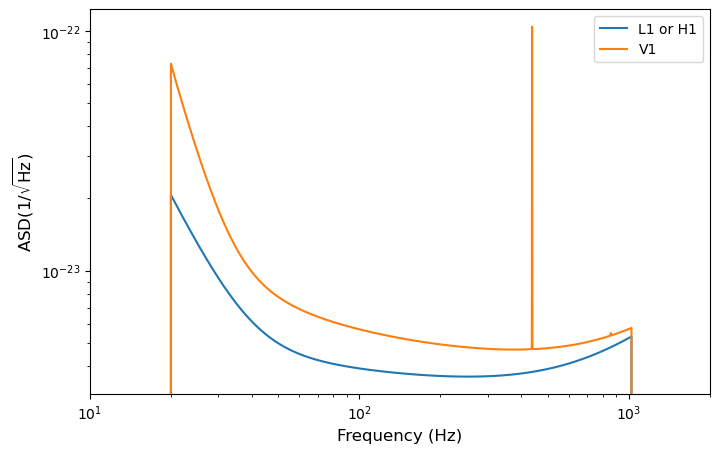

In [5]:
plt.figure(figsize = (8, 5))
plt.loglog(psd_L1H1.sample_frequencies, np.sqrt(psd_L1H1.data), label = 'L1 or H1')
plt.loglog(psd_V1.sample_frequencies, np.sqrt(psd_V1.data), label='V1')

plt.xlabel('Frequency (Hz)', fontsize = 12)
plt.ylabel(r'ASD(1/$\sqrt{\rm{Hz}}$)', fontsize = 12)
plt.xlim(10, 2000)
plt.legend()
plt.show()

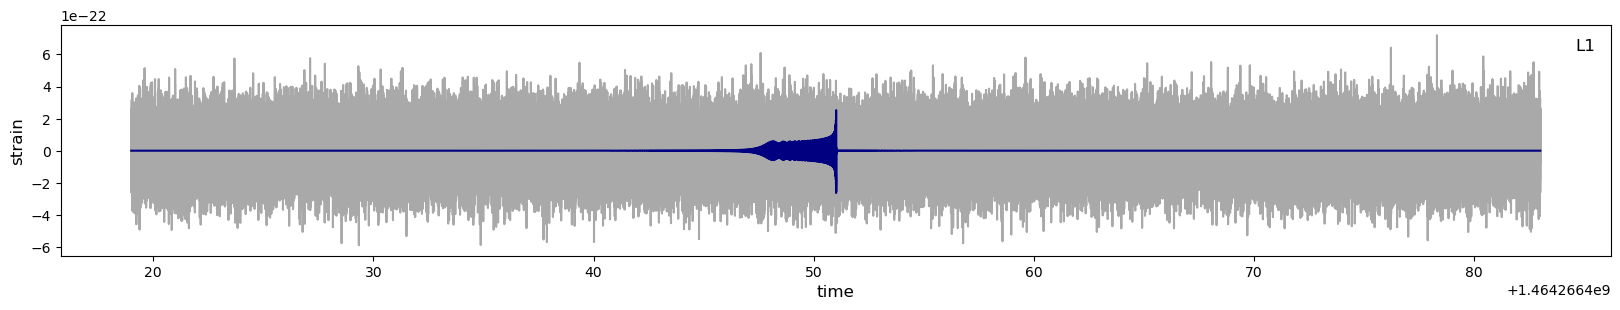

In [6]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(1, 1, sharex = True, figsize = (20, 3))
fig.subplots_adjust(hspace = 0)

ax.plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax.plot(gw_signal_td['L1'].sample_times, gw_signal_td['L1'], c = 'navy')
# ax.axvline(x = tc, c = 'k', ls = '--')
ax.set_xlabel('time', fontsize = 12)
ax.set_ylabel('strain', fontsize = 12)
ax.set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
# ax[0].set_xlim(tc - 0.1, tc + 0.1)

plt.show()

In [7]:
# Whiten the signal and data.
print('Whitening the signal and data.')

whitened_h_td = {}
whitened_data_td = {}

for detector in ifos:
    
    whitened_h_td[detector] = whiten(gw_signal[detector], psd[detector])
    whitened_data_td[detector] = whiten(data_fd[detector], psd[detector])

Whitening the signal and data.


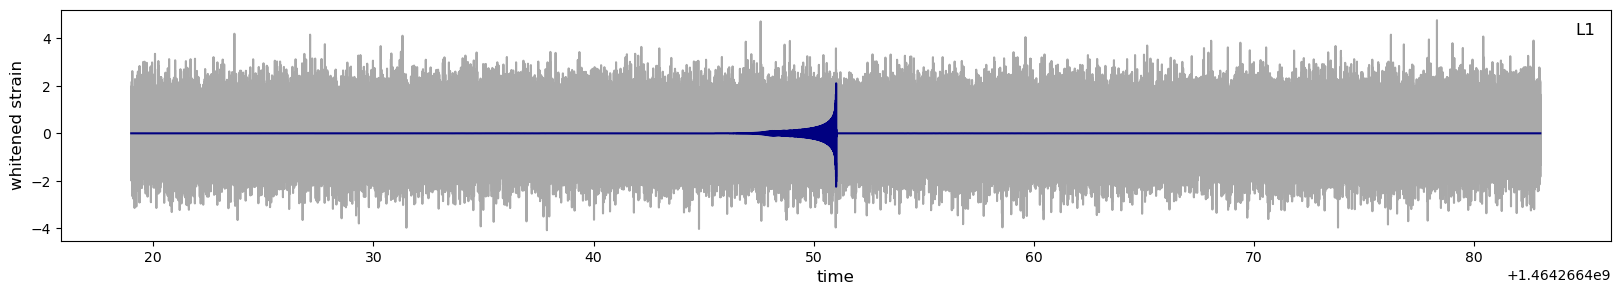

In [8]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(1, 1, sharex = True, figsize = (20, 3))
fig.subplots_adjust(hspace = 0)

ax.plot(whitened_data_td['L1'].sample_times, whitened_data_td['L1'], c = 'darkgray')
ax.plot(whitened_h_td['L1'].sample_times, whitened_h_td['L1'], c = 'navy')
# ax.axvline(x = tc, c = 'k', ls = '--')
ax.set_xlabel('time', fontsize = 12)
ax.set_ylabel('whitened strain', fontsize = 12)
ax.set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
# ax.set_xlim(tc - 0.1, tc + 0.1)

plt.show()

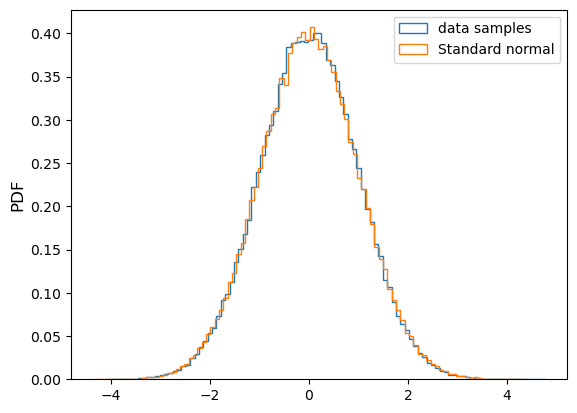

In [9]:
gaussian_samples = np.random.normal(0, 1, 100000)
whitened_data_samples = whitened_data_td['L1'].data

_ = plt.hist(whitened_data_samples, histtype = 'step', density = True, bins = 100, label = 'data samples')
_ = plt.hist(gaussian_samples, histtype='step', density = True, bins = 100, label = 'Standard normal')
plt.ylabel('PDF', fontsize = 12)
plt.legend()
plt.show()

## Matched-filter SNR

The noise-weighted inner product between two time series, $a(t)$ and $b(t)$, is defined as

$$
(a,b)
=
4\,\mathrm{Re}
\int_0^\infty
\frac{\tilde a(f)\,\tilde b^*(f)}
{S_n(f)}
\,df,
$$

where:

- $\tilde a(f)$ and $\tilde b(f)$ are the Fourier transforms of $a(t)$ and $b(t)$,
- $S_n(f)$ is the one-sided power spectral density (PSD) of the detector noise,
- and $^*$ denotes complex conjugation.

Given detector data $s(t)$ and a template waveform $h(t)$, the matched-filter output as a function of time lag is

$$
\rho(t)
=
4
\int_0^\infty
\frac{\tilde s(f)\,\tilde h^*(f)}
{S_n(f)}
e^{2\pi i f t}
\,df.
$$

The quantity $\rho(t)$ is called the **matched-filter signal-to-noise ratio (SNR) time series**. A significant peak in $|\rho(t)|$ indicates the presence of a signal in the data whose morphology is consistent with the template waveform. $h(t)$.

In [10]:
# Generate a template waveform
m1, m2, s1z, s2z = 20, 10, 0.4, -0.1

hp, hc = get_fd_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    spin1z=s1z,
    spin2z=s2z,
    distance=distance,
    delta_f=delta_f,
    f_lower=flow
)
hp.resize(Nf)
print(hp.duration)

64.0


In [11]:
complex_snr = {}
matchedFilterSNR = {}
network_snr = 0
for detector in ifos:
    
    complex_snr[detector] = matched_filter(template = hp, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh)
    matchedFilterSNR[detector] = abs(complex_snr[detector])
    network_snr += matchedFilterSNR[detector].max()**2
    print(f'SNR in detector {detector} = {matchedFilterSNR[detector].max()}')
print(f'Network SNR = {np.sqrt(network_snr)}')

SNR in detector L1 = 20.164604378070702
SNR in detector H1 = 13.597132976515795
Network SNR = 24.320635166565065


In [12]:
## Arrival time in a particular detector
det_objects = {}
arrival_time = {}
for ifo in ifos:
    det_objects[ifo] = Detector(ifo)
    # arrival_time[ifo] = tc + det_objects[ifo].time_delay_from_earth_center(ra, dec, tc)
    arrival_time[ifo] = det_objects[ifo].arrival_time(tc, ra, dec)


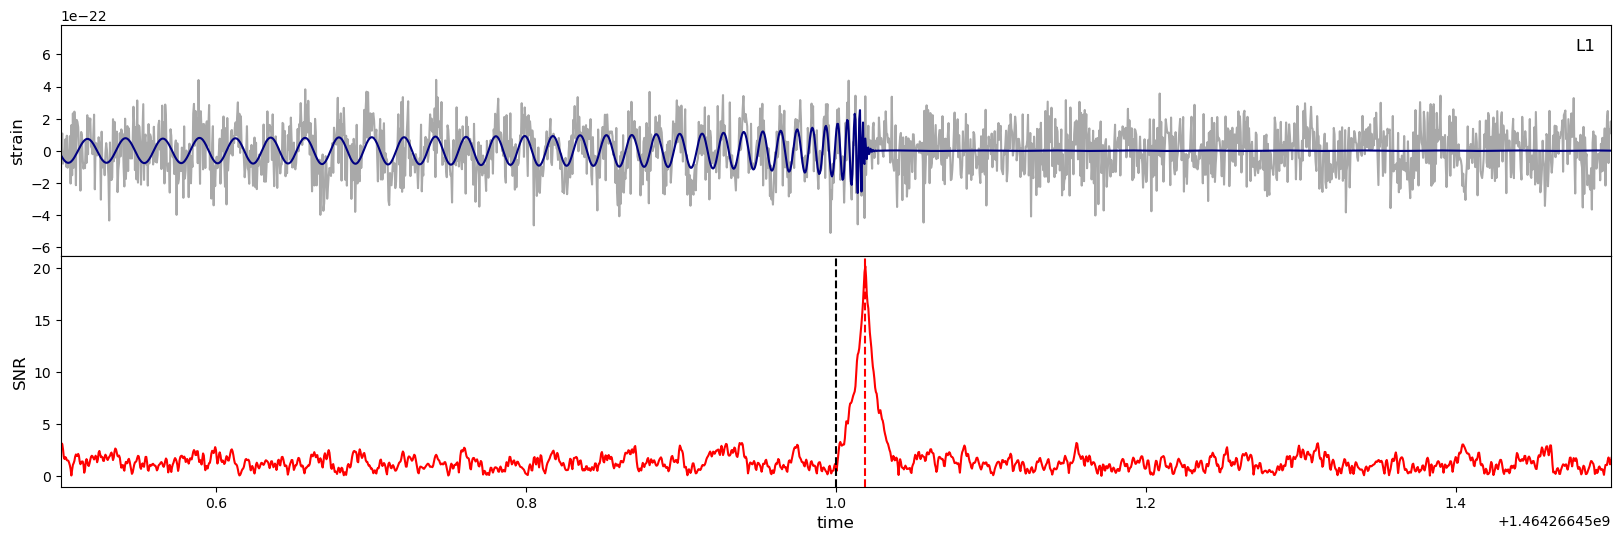

In [13]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(2, 1, sharex = True, figsize = (20, 6))
fig.subplots_adjust(hspace = 0)

ax[0].plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax[0].plot(gw_signal_td['L1'].sample_times, gw_signal_td['L1'], c = 'navy')
# ax[0].axvline(x = tc, c = 'k', ls = '--')
ax[0].set_xlabel('time', fontsize = 12)
ax[0].set_ylabel('strain', fontsize = 12)
ax[0].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
ax[0].set_xlim(tc - 0.5, tc + 0.5)

ax[1].plot(matchedFilterSNR['L1'].sample_times, matchedFilterSNR['L1'], c = 'red', label = 'L1')
ax[1].axvline(x = tc, c = 'k', ls = '--')
ax[1].axvline(x = arrival_time['L1'], c = 'red', ls = '--')
ax[1].set_xlabel('time', fontsize = 12)
ax[1].set_ylabel('SNR', fontsize = 12)
ax[1].set_xlim(tc - 0.5, tc + 0.5)

plt.show()

## What if we use different templates?

In [14]:
# Template 2
m1, m2, s1z, s2z = 19.5, 10, 0.4, -0.1

hp2, _ = get_fd_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    spin1z=s1z,
    spin2z=s2z,
    delta_f=delta_f,
    f_lower=flow
)
hp2.resize(Nf)

# Template 3
m1, m2, s1z, s2z = 25, 15, 0.4, -0.1

hp3, _ = get_fd_waveform(
    approximant='IMRPhenomD',
    mass1=m1,
    mass2=m2,
    spin1z=s1z,
    spin2z=s2z,
    delta_f=delta_f,
    f_lower=flow
)
hp3.resize(Nf)



In [15]:
matchedFilterSNR2 = {}
network_snr2 = 0
for detector in ifos:
    
    matchedFilterSNR2[detector] = abs(matched_filter(template = hp2, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh))
    print(f'SNR in detector {detector} = {matchedFilterSNR2[detector].max()}')
    network_snr2 += matchedFilterSNR2[detector].max()**2
print(f'Network SNR = {np.sqrt(network_snr2)}')

SNR in detector L1 = 14.80545856064169
SNR in detector H1 = 10.570315248529178
Network SNR = 18.19156858668781


In [16]:
matchedFilterSNR3 = {}
network_snr3 = 0
for detector in ifos:
    
    matchedFilterSNR3[detector] = abs(matched_filter(template = hp3, data = data_fd[detector], \
                                                psd=psd[detector], low_frequency_cutoff = flow, high_frequency_cutoff = fhigh))
    print(f'SNR in detector {detector} = {matchedFilterSNR3[detector].max()}')
    network_snr3 += matchedFilterSNR3[detector].max()**2
print(f'Network SNR = {np.sqrt(network_snr3)}')

SNR in detector L1 = 6.12306279922124
SNR in detector H1 = 5.683463716114643
Network SNR = 8.354259862824398


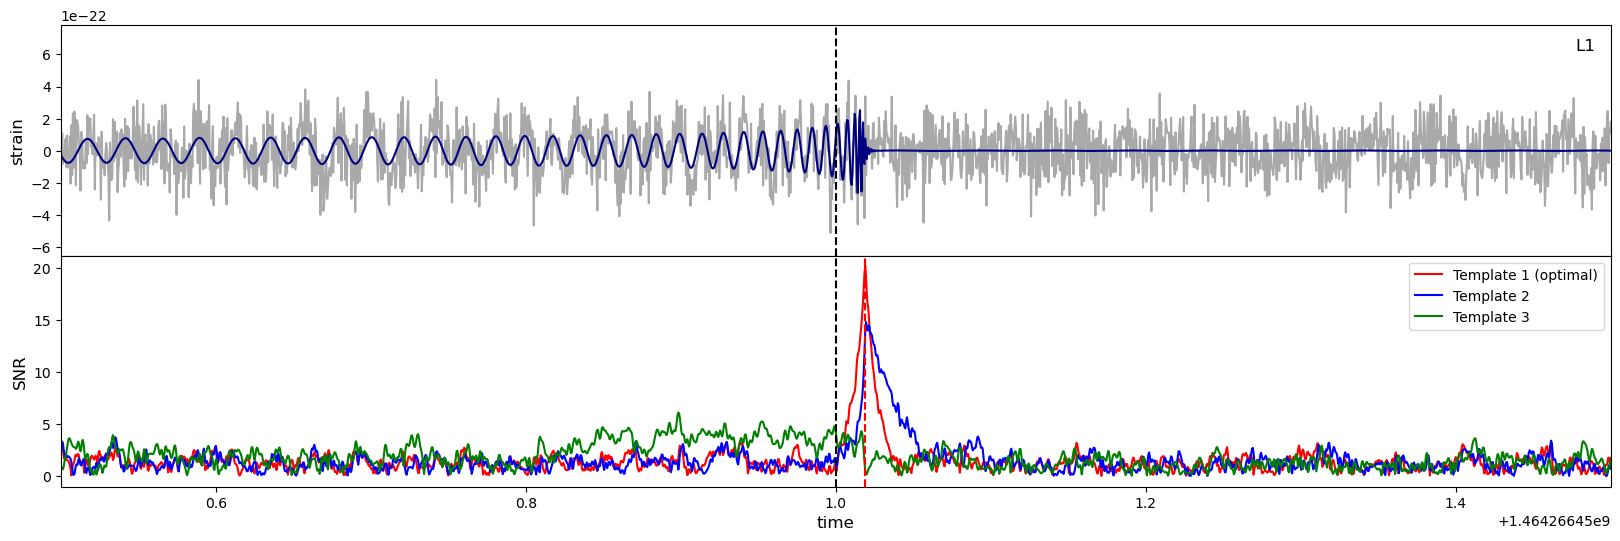

In [17]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(2, 1, sharex = True, figsize = (20, 6))
fig.subplots_adjust(hspace = 0)

ax[0].plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax[0].plot(gw_signal_td['L1'].sample_times, gw_signal_td['L1'], c = 'navy')
ax[0].axvline(x = tc, c = 'k', ls = '--')
ax[0].set_xlabel('time', fontsize = 12)
ax[0].set_ylabel('strain', fontsize = 12)
ax[0].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
ax[0].set_xlim(tc - 0.5, tc + 0.5)

ax[1].plot(matchedFilterSNR['L1'].sample_times, matchedFilterSNR['L1'], c = 'red', label = 'Template 1 (optimal)')
ax[1].plot(matchedFilterSNR2['L1'].sample_times, matchedFilterSNR2['L1'], c = 'blue', label = 'Template 2')
ax[1].plot(matchedFilterSNR3['L1'].sample_times, matchedFilterSNR3['L1'], c = 'green', label = 'Template 3')
ax[1].axvline(x = tc, c = 'k', ls = '--')
ax[1].axvline(x = arrival_time['L1'], c = 'red', ls = '--')
ax[1].set_xlabel('time', fontsize = 12)
ax[1].set_ylabel('SNR', fontsize = 12)
ax[1].set_xlim(tc - 0.5, tc + 0.5)

plt.legend()
plt.show()

## GW signal in two detectors

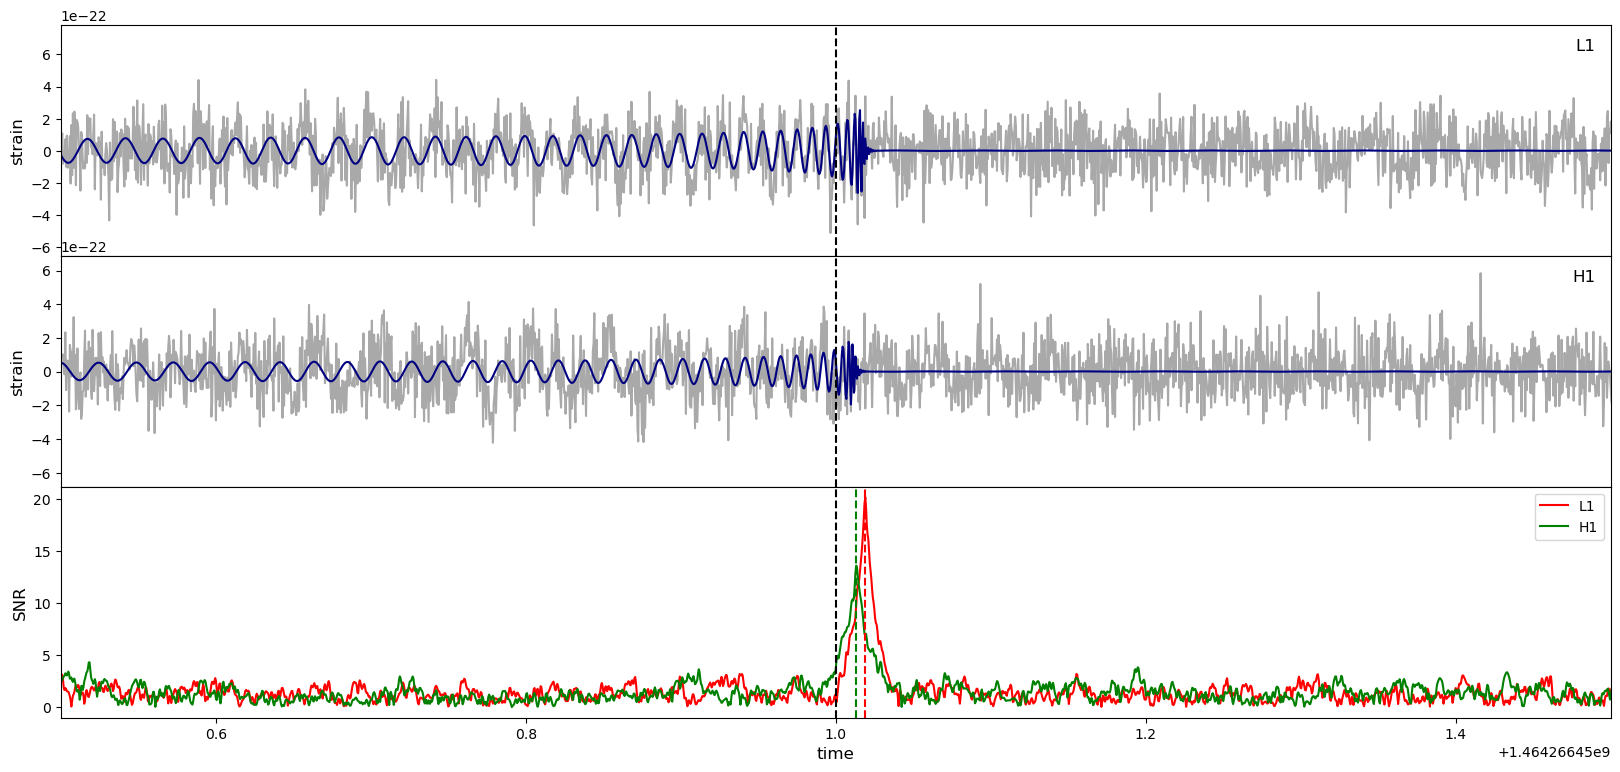

In [18]:
# Plotting whitened data and signal in three detectors.
fig, ax = plt.subplots(3, 1, sharex = True, figsize = (20, 9))
fig.subplots_adjust(hspace = 0)

ax[0].plot(data_td['L1'].sample_times, data_td['L1'], c = 'darkgray')
ax[0].plot(gw_signal_td['L1'].sample_times, gw_signal_td['L1'], c = 'navy')
ax[0].axvline(x = tc, c = 'k', ls = '--')
ax[0].axvline(x = epoch, c = 'k', ls = '--')
# ax[0].set_xlabel('time', fontsize = 12)
ax[0].set_ylabel('strain', fontsize = 12)
ax[0].set_title('L1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
# ax[0].set_xlim(tc - 0.1, tc + 0.1)

ax[1].plot(data_td['H1'].sample_times, data_td['H1'], c = 'darkgray')
ax[1].plot(gw_signal_td['H1'].sample_times, gw_signal_td['H1'], c = 'navy')
ax[1].axvline(x = tc, c = 'k', ls = '--')
ax[1].axvline(x = epoch, c = 'k', ls = '--')
# ax[1].set_xlabel('time', fontsize = 12)
ax[1].set_ylabel('strain', fontsize = 12)
ax[1].set_title('H1', x = 0.99, y = 0.95, pad = -10, fontsize = 12, loc='right')
# ax[1].set_xlim(tc - 0.1, tc + 0.1)

ax[2].plot(matchedFilterSNR['L1'].sample_times, matchedFilterSNR['L1'], c = 'red', label = 'L1')
ax[2].plot(matchedFilterSNR['H1'].sample_times, matchedFilterSNR['H1'], c = 'green', label = 'H1')
ax[2].axvline(x = tc, c = 'k', ls = '--')
ax[2].axvline(x = arrival_time['L1'], c = 'red', ls = '--')
ax[2].axvline(x = arrival_time['H1'], c = 'green', ls = '--')
ax[2].set_xlabel('time', fontsize = 12)
ax[2].set_ylabel('SNR', fontsize = 12)
ax[2].set_xlim(tc - 0.5, tc + 0.5)

plt.legend()
plt.show()

## What can we say about the source position?
The difference in the trigger times at two different detectors encodes the information of source position.

In [19]:
ra_pts = np.linspace(0, 2*np.pi, 100)
dec_pts = np.linspace(-np.pi/2, np.pi/2, 100)

ra_grid, dec_grid = np.meshgrid(ra_pts, dec_pts)

time_delays = np.zeros(ra_grid.shape)
for i in range(dec_grid.shape[0]):
    for j in range(dec_grid.shape[1]):
        time_delays[i, j] = det_objects['L1'].time_delay_from_detector(det_objects['H1'], ra_grid[i, j], dec_grid[i, j], tc)

indices = np.where(np.logical_and(time_delays <= arrival_time['L1'] - arrival_time['H1'], time_delays > 0))

mask = np.logical_and(time_delays <= arrival_time['L1'] - arrival_time['H1'],time_delays > 0)

ra_selected = ra_grid[mask]
dec_selected = dec_grid[mask]

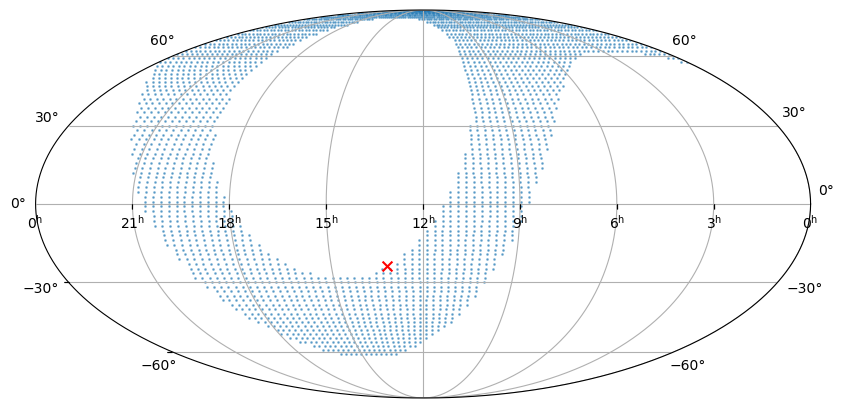

In [20]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='astro hours mollweide')

ax.scatter(np.degrees(ra_selected), np.degrees(dec_selected), s=1, alpha=0.5, transform=ax.get_transform('world'))
ax.scatter(np.degrees(ra), np.degrees(dec), s=50, color = 'red', marker = 'x', transform=ax.get_transform('world'))

ax.grid(True)
plt.show()

## Exercise
### Repeat the above example including Virgo (V1).
- Compare the SNR time series in three detectors (L1, H1, and V1).
- Check how does the source sky-localization improves.